In [28]:
# libraries
import numpy as np
import pandas as pd
import random
import seaborn as sns
sns.set(style="ticks", color_codes=True)
from sklearn import neighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [16]:
#wine data set
#Columns/Features
D = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
L = 'quality'
C = 'color'

DL = D + [L]
DC = D + [C]
DLC = DL + [C]

#Loading Data set
wine_r = pd.read_csv("winequality-red.csv", sep=';')
#Loading Data set
wine_w = pd.read_csv("winequality-white.csv", sep=';')
wine_w= wine_w.copy()
wine_w[C]= np.zeros(wine_w.shape[0])
wine_r[C]= np.ones(wine_r.shape[0])
wine = pd.concat([wine_w,wine_r])




Data: shape=(2088, 12)


'describe'

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03
mean,-1.990745e-16,-5.955219e-17,-1.276118e-17,5.785070e-17,1.531342e-17,5.104474e-17,6.465667e-17,-9.890768e-15,-5.699996e-16,1.446268e-16,-5.836115e-16,-4.789698e-16
std,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00
min,-2.255718e+00,-1.678267e+00,-1.853090e+00,-8.667199e-01,-2.561067e+00,-1.445983e+00,-1.415766e+00,-2.881097e+00,-3.196268e+00,-2.319050e+00,-2.179119e+00,-3.244119e+00
25%,-5.990508e-01,-7.703616e-01,-5.383806e-01,-6.265268e-01,-8.507948e-01,-8.019780e-01,-9.382729e-01,-6.634160e-01,-6.653677e-01,-6.633334e-01,-8.863086e-01,-9.326633e-01
50%,-1.848841e-01,-2.897057e-01,2.506606e-02,-5.064302e-01,-5.266786e-02,-1.579730e-01,-6.561275e-02,1.227853e-01,-1.792806e-02,-1.335041e-01,-1.106223e-01,2.230643e-01
75%,3.673383e-01,6.716062e-01,5.885128e-01,4.063037e-01,9.734953e-01,6.031238e-01,7.082557e-01,7.309788e-01,6.883698e-01,5.287827e-01,6.650641e-01,2.230643e-01
max,5.199283e+00,4.997510e+00,3.843983e+00,6.531229e+00,1.543586e+00,5.989348e+00,4.149501e+00,5.603944e+00,4.396433e+00,6.952964e+00,2.992123e+00,3.690247e+00


'skew:'

fixed acidity           1.436999
volatile acidity        1.017922
citric acid             0.081687
residual sugar          1.764316
chlorides              -0.101761
free sulfur dioxide     1.111912
total sulfur dioxide    0.447947
density                -0.252960
pH                      0.262094
sulphates               0.982497
alcohol                 0.591318
quality                 0.236127
dtype: float64

...

fixed acidity           2.836630
volatile acidity        1.024529
citric acid             0.024045
residual sugar          2.811984
chlorides              -1.203560
free sulfur dioxide     2.017716
total sulfur dioxide   -0.710709
density                -0.006969
pH                      0.319761
sulphates               2.333795
alcohol                -0.413355
quality                 0.232516
dtype: float64

'variance'

fixed acidity           1.00024
volatile acidity        1.00024
citric acid             1.00024
residual sugar          1.00024
chlorides               1.00024
free sulfur dioxide     1.00024
total sulfur dioxide    1.00024
density                 1.00024
pH                      1.00024
sulphates               1.00024
alcohol                 1.00024
quality                 1.00024
dtype: float64

'range:'

fixed acidity           7.455001
volatile acidity        6.675777
citric acid             5.697072
residual sugar          7.397949
chlorides               4.104653
free sulfur dioxide     7.435331
total sulfur dioxide    5.565267
density                 8.485041
pH                      7.592702
sulphates               9.272014
alcohol                 5.171242
quality                 6.934366
dtype: float64

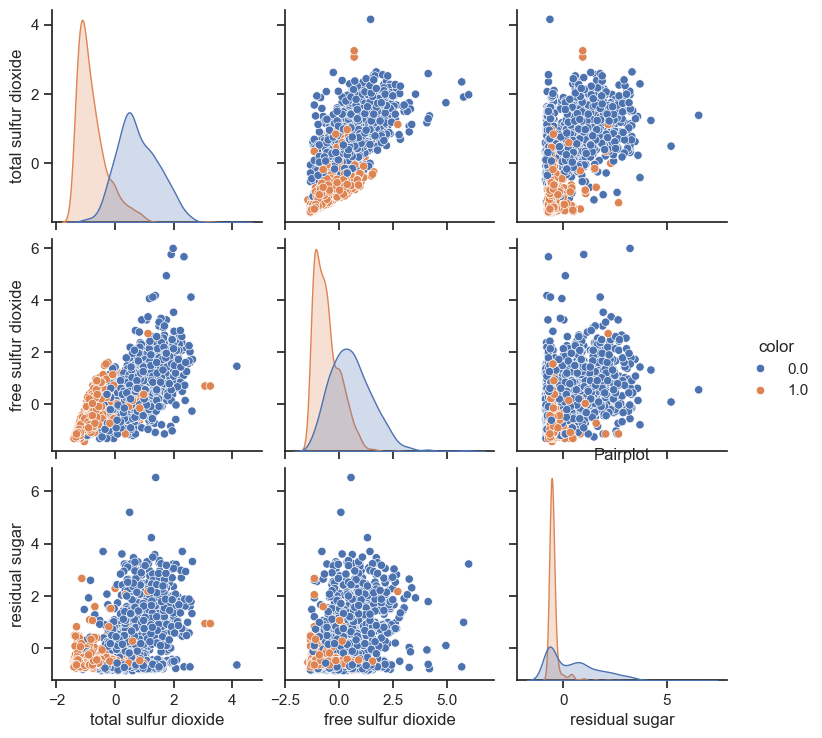

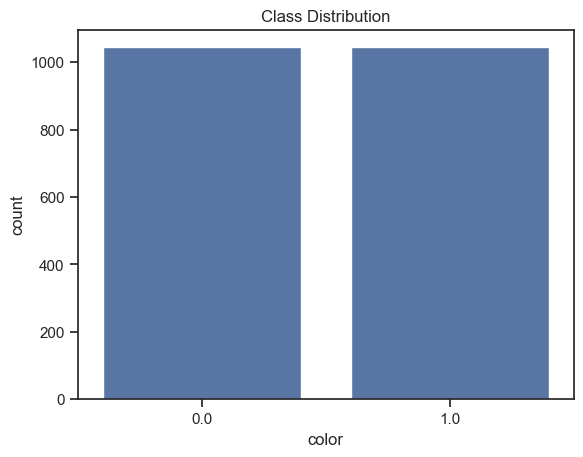

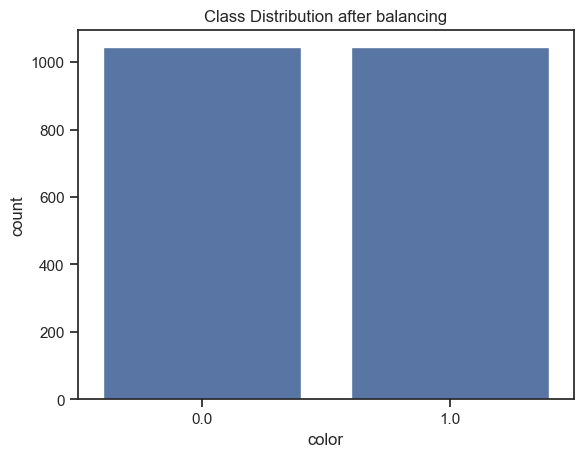

'describe'

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03,2.088000e+03
mean,-1.020895e-17,6.805965e-18,-1.361193e-17,-1.956715e-17,1.020895e-17,3.232833e-17,1.361193e-17,1.361193e-17,1.701491e-17,-8.507456e-18,1.871640e-17,9.783575e-18
std,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00,1.000240e+00
min,-2.255718e+00,-1.678267e+00,-1.853090e+00,-8.667199e-01,-2.561067e+00,-1.445983e+00,-1.415766e+00,-2.881097e+00,-3.196268e+00,-2.319050e+00,-2.179119e+00,-3.244119e+00
25%,-5.990508e-01,-7.703616e-01,-5.383806e-01,-6.265268e-01,-8.507948e-01,-8.019780e-01,-9.382729e-01,-6.634160e-01,-6.653677e-01,-6.633334e-01,-8.863086e-01,-9.326633e-01
50%,-1.848841e-01,-2.897057e-01,2.506606e-02,-5.064302e-01,-5.266786e-02,-1.579730e-01,-6.561275e-02,1.227853e-01,-1.792806e-02,-1.335041e-01,-1.106223e-01,2.230643e-01
75%,3.673383e-01,6.716062e-01,5.885128e-01,4.063037e-01,9.734953e-01,6.031238e-01,7.082557e-01,7.309788e-01,6.883698e-01,5.287827e-01,6.650641e-01,2.230643e-01
max,5.199283e+00,4.997510e+00,3.843983e+00,6.531229e+00,1.543586e+00,5.989348e+00,4.149501e+00,5.603944e+00,4.396433e+00,6.952964e+00,2.992123e+00,3.690247e+00


In [30]:

print(f'Data: shape={wine[DL].shape}')
display("describe",wine[DL].describe())
display("skew:",wine[DL].skew())
display("kurtosis", wine[DL].kurtosis())
display("variance", wine[DL].std())

feature_range = wine[DL].max() - wine[DL].min()
display("range:")
display(feature_range)

# sns.histplot(wine['chlorides'], bins=30, kde=True)  
# plt.title("Feature Distribution")
# plt.show()

#removing outliers from high kurtosis features
Q1 = wine['chlorides'].quantile(0.25)
Q3 = wine['chlorides'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
wine = wine[(wine['chlorides'] >= lower_bound) & (wine['chlorides'] <= upper_bound)]

subset = ['total sulfur dioxide', 'free sulfur dioxide', 'residual sugar', 'color']
sns.pairplot(wine[subset], hue='color')
plt.title("Pairplot")
plt.show()

sns.countplot(x =wine[C])
plt.title("Class Distribution")
plt.show()

#generate balanced train and test splits and shuffle the data
white_wine = wine[wine[C] == 0]
red_wine = wine[wine[C] == 1]
white_sampled = white_wine.sample(n=len(red_wine), random_state=42)
wine = pd.concat([white_sampled, red_wine])
wine = wine.sample(frac=1, random_state=42)

sns.countplot(x =wine[C])
plt.title("Class Distribution after balancing")
plt.show()

#z-score normalization
scaler = StandardScaler()
wine = wine.astype(float)
wine.iloc[:, :-1] = scaler.fit_transform(wine.iloc[:, :-1])

display("describe",wine[DL].describe())




In [ ]:
#KNN Classifer  
# Create Train/Test Split
ran = 42
train_size = .8
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state = ran) 

In [2]:
#Decision Tree Classifier

In [ ]:
#Random Forest Classifier

In [ ]:
#Summarize Results